In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# load Data

In [5]:


# Configuration
sns.set(style="whitegrid")
DATA_PATH = Path("data")

# Fonction de chargement
def load_imdb_data(split="train"):
    texts = []
    labels = []
    for label_type in ["pos", "neg"]:
        dir_path = DATA_PATH / split / label_type
        for fname in os.listdir(dir_path):
            with open(dir_path / fname, encoding="utf-8") as f:
                texts.append(f.read())
                labels.append(1 if label_type == "pos" else 0)
    return pd.DataFrame({"review": texts, "label": labels})

# Chargement des jeux de données
train_df = load_imdb_data("train")
test_df = load_imdb_data("test")




In [3]:
# Aperçu
print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
display(train_df.sample(3))

Train size: 25000 | Test size: 25000


,review,label
1942,Finally we get a TV series where we get to see...,1
24766,Basically this is about a couple who want to a...,0
5668,Viewing DE VIERDE MAN (aka THE FOURTH MAN) is ...,1


In [6]:
# Ajout de la longueur de chaque review
train_df["review_length"] = train_df["review"].apply(lambda x: len(x.split()))
test_df["review_length"] = test_df["review"].apply(lambda x: len(x.split()))

C:\Users\Hp\AppData\Local\Temp\ipykernel_17268\3040776543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Négatif", "Positif"])
C:\Users\Hp\AppData\Local\Temp\ipykernel_17268\3040776543.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Négatif", "Positif"])


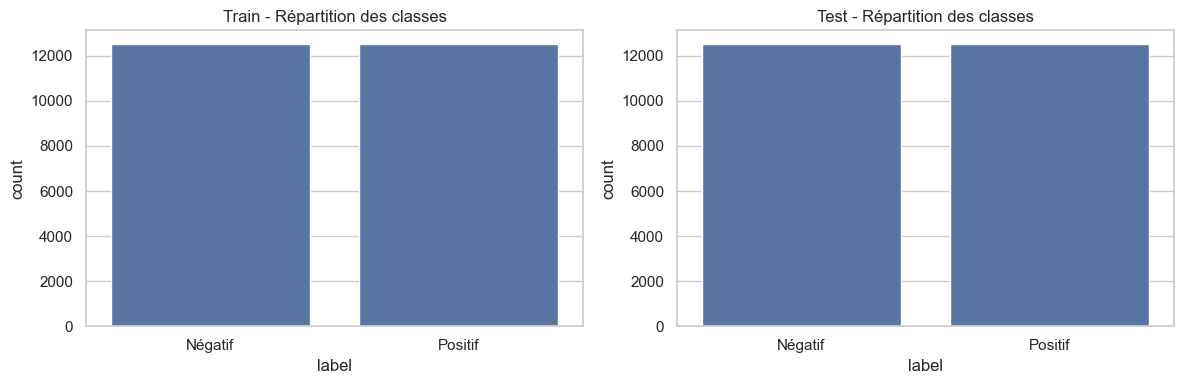

In [5]:
# Répartition des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train - Répartition des classes")
axes[0].set_xticklabels(["Négatif", "Positif"])

sns.countplot(data=test_df, x="label", ax=axes[1])
axes[1].set_title("Test - Répartition des classes")
axes[1].set_xticklabels(["Négatif", "Positif"])
plt.tight_layout()
plt.show()


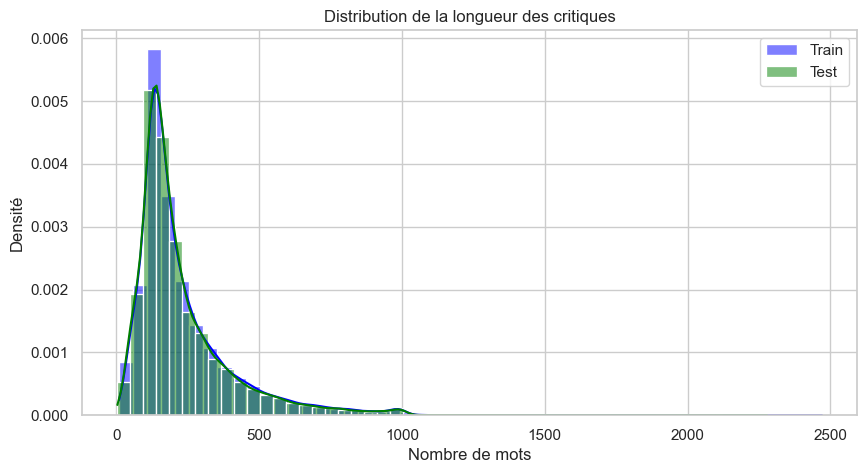

In [6]:
# Distribution des longueurs
plt.figure(figsize=(10, 5))
sns.histplot(train_df["review_length"], color="blue", bins=50, kde=True, label="Train", stat="density")
sns.histplot(test_df["review_length"], color="green", bins=50, kde=True, label="Test", stat="density")
plt.legend()
plt.title("Distribution de la longueur des critiques")
plt.xlabel("Nombre de mots")
plt.ylabel("Densité")
plt.show()

les deux datasets  sont équilibrés, avec une longueur de critique qui suit une distribution similaire.


# Word Cloud 

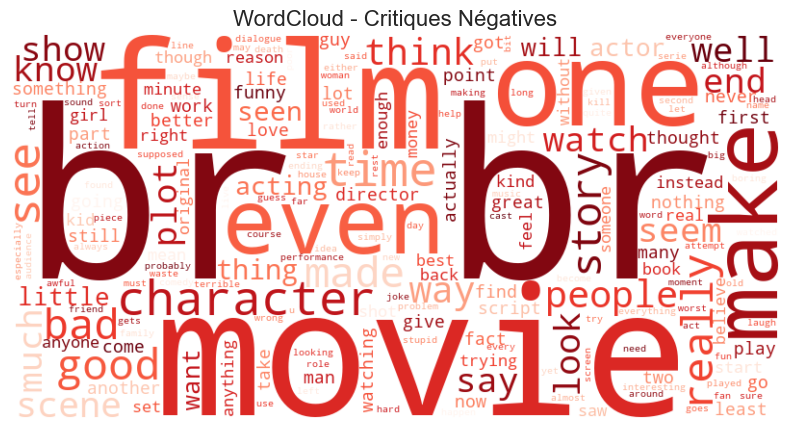

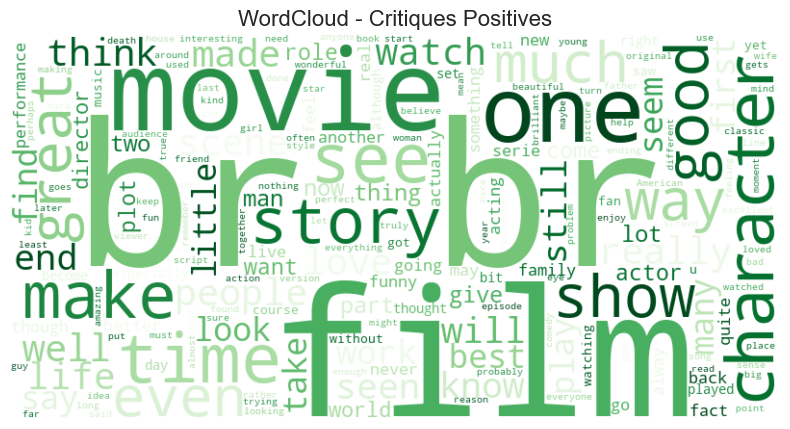

In [7]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Fusionner tous les textes d'une classe
def generate_wordcloud(df, label_value, title, color="black"):
    text = " ".join(df[df["label"] == label_value]["review"].tolist())
    stopwords = set(STOPWORDS)
    wordcloud = WordCloud(width=800, height=400, background_color="white",
                          stopwords=stopwords, colormap=color).generate(text)

    # Affichage
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Nuage de mots pour les critiques négatives
generate_wordcloud(train_df, label_value=0, title="WordCloud - Critiques Négatives", color="Reds")

# Nuage de mots pour les critiques positives
generate_wordcloud(train_df, label_value=1, title="WordCloud - Critiques Positives", color="Greens")


# Préparation des données

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Limiter le vocabulaire à 5000 mots, pas de stopwords
vectorizer = CountVectorizer(max_features=5000, stop_words='english', binary=True)
X_train_vec = vectorizer.fit_transform(train_df["review"]).toarray()
y_train = train_df["label"].values

X_test_vec = vectorizer.transform(test_df["review"]).toarray()
y_test = test_df["label"].values

# Dictionnaire token -> index
vocab = vectorizer.vocabulary_
inv_vocab = {i: w for w, i in vocab.items()}


# Implémentation du modèle : Semantic + Sentiment (inspiré du papier)

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SentimentWordVectorModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.bias = nn.Parameter(torch.zeros(vocab_size))  # b_w
        self.classifier = nn.Linear(embed_dim, 1)  # ψ

    def forward(self, bow_input):
        # bow_input : batch_size × vocab_size
        θ = bow_input @ self.embed.weight / bow_input.sum(1, keepdim=True)  # équivalent à moyenne pondérée
        logits = self.classifier(θ).squeeze(1)
        return logits

    def get_word_vectors(self):
        return self.embed.weight.data.cpu().numpy()


#  Entraînement (supervisé avec logistic loss)

In [10]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# Tensors
X_train_tensor = torch.tensor(X_train_vec, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vec, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

# Model
model = SentimentWordVectorModel(vocab_size=5000, embed_dim=50)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

# Entraînement
for epoch in range(10):
    model.train()
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 2 == 0:
        model.eval()
        with torch.no_grad():
            logits = model(X_test_tensor)
            preds = torch.sigmoid(logits).round()
            acc_test = accuracy_score(y_test_tensor.numpy(), preds.numpy())
            acc_train = accuracy_score(y_train_tensor.numpy(), torch.sigmoid(model(X_train_tensor)).round().numpy())
            print(f"Epoch {epoch+1} - Train Accuracy: {acc_train:.4f} - Test Accuracy: {acc_test:.4f}")



        
    


Epoch 1 - Train Accuracy: 0.8214 - Test Accuracy: 0.8017
Epoch 3 - Train Accuracy: 0.8842 - Test Accuracy: 0.8632
Epoch 5 - Train Accuracy: 0.9047 - Test Accuracy: 0.8721
Epoch 7 - Train Accuracy: 0.9151 - Test Accuracy: 0.8752
Epoch 9 - Train Accuracy: 0.9229 - Test Accuracy: 0.8751


# Evaluation

In [11]:
model.eval()
with torch.no_grad():
    preds = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
    preds_class = (preds > 0.5).astype(int)
    acc = accuracy_score(y_test, preds_class)
    print(f"Test Accuracy: {acc:.4f}")


Test Accuracy: 0.8742


# approche du papier 

apprentissage des vecteurs de mots en maximisant la log vraisemblance 

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SemanticLikelihoodModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.word_embeddings = nn.Parameter(torch.randn(vocab_size, embed_dim) * 0.01)  # φ_w
        self.bias = nn.Parameter(torch.zeros(vocab_size))                                # b_w

    def forward(self, bow_input):
        """
        bow_input: [batch_size, vocab_size] (binary vector of word presence)
        """
        batch_size = bow_input.size(0)
        device = bow_input.device

        # Initialise un vecteur θ par document, avec requires_grad pour l'optimiser
        theta = torch.randn(batch_size, self.word_embeddings.shape[1], requires_grad=True, device=device)

        # Softmax (logits = θ @ φ^T + b)
        logits = torch.matmul(theta, self.word_embeddings.T) + self.bias  # [batch, vocab]
        log_probs = F.log_softmax(logits, dim=1)

        # Calcul de la log-vraisemblance sur les mots présents dans le doc
        log_likelihood = torch.sum(bow_input * log_probs, dim=1).mean()

        return -log_likelihood  # on retourne la loss (négative log-vraisemblance)


Epoch 1 - Train NLL: 591.6081 | Test NLL: 564.8935
Epoch 2 - Train NLL: 570.2218 | Test NLL: 549.7148
Epoch 3 - Train NLL: 559.1179 | Test NLL: 542.0079
Epoch 4 - Train NLL: 553.5381 | Test NLL: 538.7334
Epoch 5 - Train NLL: 551.4281 | Test NLL: 537.6138
Epoch 6 - Train NLL: 550.8741 | Test NLL: 537.3280
Epoch 7 - Train NLL: 550.7929 | Test NLL: 537.2504
Epoch 8 - Train NLL: 550.8653 | Test NLL: 537.2014
Epoch 9 - Train NLL: 550.7487 | Test NLL: 537.2138
Epoch 10 - Train NLL: 550.7906 | Test NLL: 537.2026


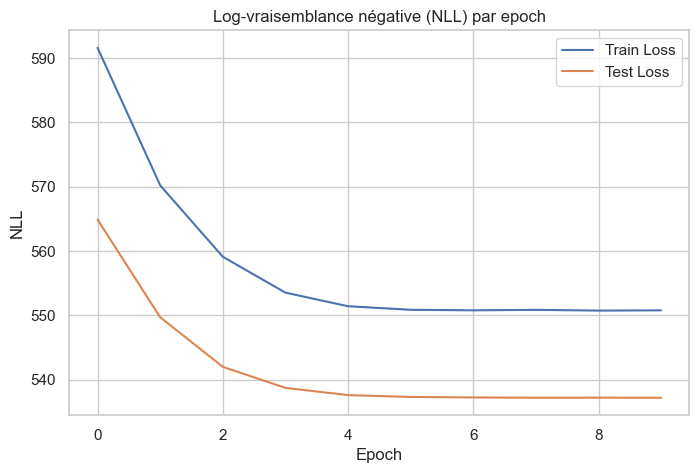

In [13]:
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size)

model = SemanticLikelihoodModel(vocab_size=X_train_tensor.shape[1], embed_dim=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses = []
test_losses = []

for epoch in range(10):
    model.train()
    train_loss = 0
    for X_batch, in train_loader:
        X_batch = X_batch.to(device)
        loss = model(X_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        test_loss = 0
        for X_batch, in test_loader:
            X_batch = X_batch.to(device)
            loss = model(X_batch)
            test_loss += loss.item()
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

    print(f"Epoch {epoch+1} - Train NLL: {avg_train_loss:.4f} | Test NLL: {avg_test_loss:.4f}")

# 📈 Tracer les deux courbes
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Log-vraisemblance négative (NLL) par epoch")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.legend()
plt.grid(True)
plt.show()

# Entrainement d'une regression logistic sur les vecteurs de documents appris 

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# Étape 1 – Représentation des documents par moyenne pondérée des φw
def compute_document_vectors(bow_matrix, word_vectors):
    doc_vecs = bow_matrix @ word_vectors
    lengths = bow_matrix.sum(axis=1, keepdims=True) + 1e-10
    return doc_vecs / lengths

# Conversion tensor → numpy
X_train_bow = X_train_tensor.numpy()
X_test_bow = X_test_tensor.numpy()

# Moyenne des vecteurs de mots φw
phi_w = model.word_embeddings.detach().cpu().numpy()
X_train_repr = compute_document_vectors(X_train_bow, phi_w)
X_test_repr = compute_document_vectors(X_test_bow, phi_w)

# Étape 2 – Recherche d'hyperparamètre pour C (régularisation)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
clf = LogisticRegression(max_iter=1000)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_repr, y_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleur paramètre C :", grid_search.best_params_['C'])

# Étape 3 – Évaluation finale
train_preds = best_model.predict(X_train_repr)
test_preds = best_model.predict(X_test_repr)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")


Meilleur paramètre C : 100
Train Accuracy: 0.6925
Test Accuracy:  0.6905


# Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [5, 10,80],
    'max_depth': [5, 10, 20],
    
}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_repr, y_train)

rf_best = rf_grid.best_estimator_
print("Random Forest - Best Params:", rf_grid.best_params_)
print("Train Accuracy:", accuracy_score(y_train, rf_best.predict(X_train_repr)))
print("Test Accuracy :", accuracy_score(y_test, rf_best.predict(X_test_repr)))


Random Forest - Best Params: {'max_depth': 10, 'n_estimators': 80}
Train Accuracy: 0.8708
Test Accuracy : 0.679


# Xgboost

In [16]:
from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [10, 100],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_repr, y_train)

xgb_best = xgb_grid.best_estimator_
print("XGBoost - Best Params:", xgb_grid.best_params_)
print("Train Accuracy:", accuracy_score(y_train, xgb_best.predict(X_train_repr)))
print("Test Accuracy :", accuracy_score(y_test, xgb_best.predict(X_test_repr)))


XGBoost - Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Train Accuracy: 0.84096
Test Accuracy : 0.68252


# Modèle Bert

In [7]:
from datasets import Dataset


# Préparation des données 
# train_df et test_df doivent contenir deux colonnes : 'text' et 'label'
train_df = train_df.rename(columns={"review": "text"})
test_df = test_df.rename(columns={"review": "text"})

#Convertir en Dataset HuggingFace

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)


In [8]:
# Tokenisation avec BERT
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)


Map: 100%|██████████| 25000/25000 [00:31<00:00, 796.07 examples/s]


In [ ]:
# Charger le modèle de classification
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


: 

In [ ]:
# Entraînement avec Trainer

from transformers import TrainingArguments, Trainer
import evaluate

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return accuracy.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir="./bert-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss


In [ ]:
results = trainer.evaluate()
print(f"Test Accuracy: {results['eval_accuracy']:.4f}")